In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

train_df = pd.read_csv("../data/processed/train_uci_household.csv", index_col="datetime", parse_dates=True)
val_df = pd.read_csv("../data/processed/val_uci_household.csv", index_col="datetime", parse_dates=True)
test_df = pd.read_csv("../data/processed/test_uci_household.csv", index_col="datetime", parse_dates=True)

print("Data loaded:", train_df.shape, val_df.shape, test_df.shape)

Data loaded: (269772, 26) (62256, 26) (83007, 26)


In [3]:
WINDOW = 12
feature_set = ["Global_active_power", "Voltage", "Global_intensity", "Global_reactive_power"]

def build_multivariate_sequences(df, window=WINDOW, features=feature_set):
    values = df[features].values
    targets = df["target_5min"].values
    n = len(values) - window
    X = np.array([values[i:i+window] for i in range(n)])
    y = targets[window:]
    return X, y

X_train_raw, y_train = build_multivariate_sequences(train_df)
X_val_raw, y_val = build_multivariate_sequences(val_df)
X_test_raw, y_test = build_multivariate_sequences(test_df)

print(X_train_raw.shape, X_val_raw.shape, X_test_raw.shape)

(269760, 12, 4) (62244, 12, 4) (82995, 12, 4)


In [4]:
n_features = X_train_raw.shape[2]

scaler = StandardScaler()
X_train_flat = X_train_raw.reshape(-1, n_features)
scaler.fit(X_train_flat)

def scale_sequences(X_raw, scaler, window=WINDOW, n_features=n_features):
    flat = X_raw.reshape(-1, n_features)
    scaled_flat = scaler.transform(flat)
    return scaled_flat.reshape(-1, window, n_features)

X_train_scaled = scale_sequences(X_train_raw, scaler)
X_val_scaled = scale_sequences(X_val_raw, scaler)
X_test_scaled = scale_sequences(X_test_raw, scaler)

print(X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

(269760, 12, 4) (62244, 12, 4) (82995, 12, 4)


In [5]:
def build_tcn(input_shape, filters=32, kernel_size=3, dilations=[1, 2, 4, 8]):
    inputs = tf.keras.Input(shape=input_shape)
    x = inputs
    for d in dilations:
        conv = tf.keras.layers.Conv1D(
            filters=filters, kernel_size=kernel_size,
            dilation_rate=d, padding="causal", activation="relu"
        )(x)
        if x.shape[-1] != filters:
            x = tf.keras.layers.Conv1D(filters=filters, kernel_size=1, padding="same")(x)
        x = tf.keras.layers.Add()([x, conv])
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(32, activation="relu")(x)
    outputs = tf.keras.layers.Dense(1)(x)
    return tf.keras.Model(inputs, outputs)

tcn_model = build_tcn(input_shape=(WINDOW, n_features))
tcn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="mse", metrics=["mae"])
tcn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 12, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 12, 32)    │        160 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 12, 32)    │        416 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 12, 32)    │          0 │ conv1d_1[0][0],   │
│                     │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 12, 32)    │      3,104 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 12, 32)    │          0 │ add[0][0],        │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 12, 32)    │      3,104 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 12, 32)    │          0 │ add_1[0][0],      │
│                     │                   │            │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 12, 32)    │      3,104 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 12, 32)    │          0 │ add_2[0][0],      │
│                     │                   │            │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ add_3[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,056 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         33 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,977 (42.88 KB)

 Trainable params: 10,977 (42.88 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = tcn_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
4215/4215 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 0.3704 - mae: 0.3485 - val_loss: 0.3033 - val_mae: 0.3079
Epoch 2/30
4215/4215 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - loss: 0.3328 - mae: 0.3206 - val_loss: 0.2993 - val_mae: 0.3134
Epoch 3/30
4215/4215 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.3245 - mae: 0.3131 - val_loss: 0.3132 - val_mae: 0.3484
Epoch 4/30
4215/4215 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.3198 - mae: 0.3086 - val_loss: 0.2891 - val_mae: 0.2921
Epoch 5/30
4215/4215 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.3172 - mae: 0.3064 - val_loss: 0.2849 - val_mae: 0.2924
Epoch 6/30
4215/4215 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.3147 - mae: 0.3043 - val_loss: 0.2953 - val_mae: 0.2874
Epoch 7/30
4215/4215 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.3123 - mae: 0.3029 - val_loss: 0.2836 - val_mae: 0.3055
Epoch 8/30
4215/4215 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - loss: 0.3108 - mae: 0.3020 - val_loss: 0.2821 - val_mae: 0.3014
Epoch 9/30
4215/4215 ━━━━━━━━━━━

In [7]:
y_pred_tcn = tcn_model.predict(X_test_scaled).flatten()

rmse_tcn = np.sqrt(mean_squared_error(y_test, y_pred_tcn))
mae_tcn = mean_absolute_error(y_test, y_pred_tcn)
r2_tcn = r2_score(y_test, y_pred_tcn)
wmape_tcn = np.sum(np.abs(y_test - y_pred_tcn)) / np.sum(np.abs(y_test)) * 100

print(f"TCN (multi-feature) — RMSE: {rmse_tcn:.4f}  MAE: {mae_tcn:.4f}  R2: {r2_tcn:.4f}  wMAPE: {wmape_tcn:.2f}%")

2594/2594 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
TCN (multi-feature) — RMSE: 0.4850  MAE: 0.2806  R2: 0.6784  wMAPE: 27.97%


In [8]:
comparison = pd.DataFrame({
    "Model": ["LSTM (baseline)", "TCN v1 (single-feature)", "TCN v2 (multi-feature)"],
    "RMSE": [0.3166, 0.4933, rmse_tcn],
    "MAE": [0.1813, 0.2828, mae_tcn],
    "R2": [0.8630, 0.6674, r2_tcn],
    "wMAPE (%)": [18.07, 28.19, wmape_tcn]
})
print(comparison)

                     Model      RMSE      MAE        R2  wMAPE (%)
0          LSTM (baseline)  0.316600  0.18130  0.863000  18.070000
1  TCN v1 (single-feature)  0.493300  0.28280  0.667400  28.190000
2   TCN v2 (multi-feature)  0.485048  0.28063  0.678421  27.969896


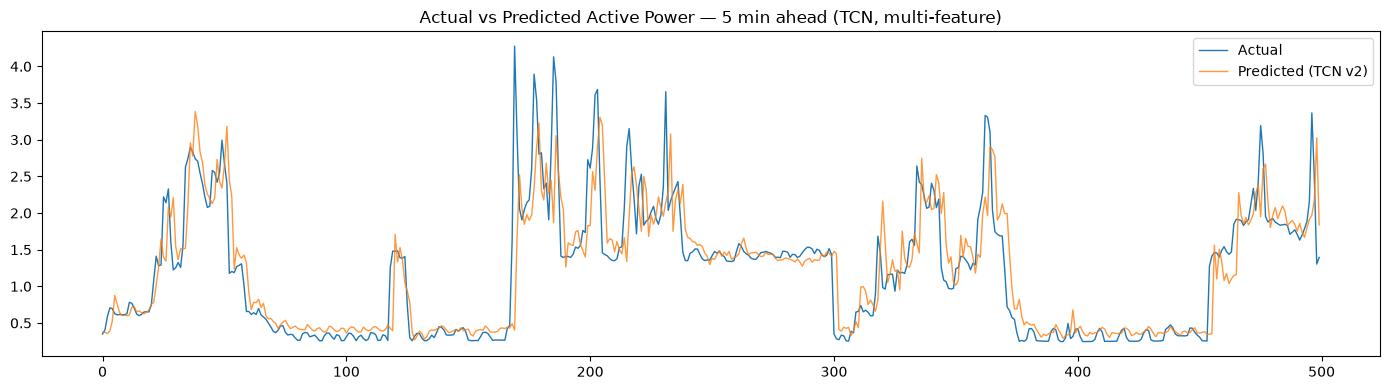

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(range(500), y_test[:500], label="Actual", linewidth=1)
ax.plot(range(500), y_pred_tcn[:500], label="Predicted (TCN v2)", linewidth=1, alpha=0.8)
ax.set_title("Actual vs Predicted Active Power — 5 min ahead (TCN, multi-feature)")
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
engineered_features = [
    "Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity",
    "Global_active_power_lag_1", "Global_active_power_lag_2", "Global_active_power_lag_3",
    "Global_active_power_lag_6", "Global_active_power_lag_12",
    "Global_active_power_roll_mean_3", "Global_active_power_roll_std_3",
    "Global_active_power_roll_mean_6", "Global_active_power_roll_std_6",
    "Global_active_power_roll_mean_12", "Global_active_power_roll_std_12",
    "hour_sin", "hour_cos", "is_weekend"
]

WINDOW = 12

def build_full_sequences(df, window=WINDOW, features=engineered_features):
    values = df[features].values
    targets = df["target_5min"].values
    n = len(values) - window
    X = np.array([values[i:i+window] for i in range(n)])
    y = targets[window:]
    return X, y

X_train_raw2, y_train2 = build_full_sequences(train_df)
X_val_raw2, y_val2 = build_full_sequences(val_df)
X_test_raw2, y_test2 = build_full_sequences(test_df)

print(X_train_raw2.shape, X_val_raw2.shape, X_test_raw2.shape)

(269760, 12, 18) (62244, 12, 18) (82995, 12, 18)


In [12]:
n_features2 = X_train_raw2.shape[2]

scaler2 = StandardScaler()
scaler2.fit(X_train_raw2.reshape(-1, n_features2))

def scale_seq(X_raw, scaler, window=WINDOW, n_features=n_features2):
    flat = X_raw.reshape(-1, n_features)
    return scaler.transform(flat).reshape(-1, window, n_features)

X_train_scaled2 = scale_seq(X_train_raw2, scaler2)
X_val_scaled2 = scale_seq(X_val_raw2, scaler2)
X_test_scaled2 = scale_seq(X_test_raw2, scaler2)

print(X_train_scaled2.shape)

(269760, 12, 18)


In [13]:
tcn_model_v3 = build_tcn(input_shape=(WINDOW, n_features2))
tcn_model_v3.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="mse", metrics=["mae"])

early_stop2 = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history_v3 = tcn_model_v3.fit(
    X_train_scaled2, y_train2,
    validation_data=(X_val_scaled2, y_val2),
    epochs=30, batch_size=64,
    callbacks=[early_stop2], verbose=1
)

Epoch 1/30
4215/4215 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 0.3636 - mae: 0.3551 - val_loss: 0.2978 - val_mae: 0.3272
Epoch 2/30
4215/4215 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - loss: 0.3244 - mae: 0.3250 - val_loss: 0.2827 - val_mae: 0.3102
Epoch 3/30
4215/4215 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - loss: 0.3107 - mae: 0.3141 - val_loss: 0.2768 - val_mae: 0.3029
Epoch 4/30
4215/4215 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.3046 - mae: 0.3090 - val_loss: 0.2722 - val_mae: 0.2998
Epoch 5/30
4215/4215 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.2997 - mae: 0.3050 - val_loss: 0.2718 - val_mae: 0.2912
Epoch 6/30
4215/4215 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - loss: 0.2960 - mae: 0.3022 - val_loss: 0.2699 - val_mae: 0.2986
Epoch 7/30
4215/4215 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.2931 - mae: 0.2999 - val_loss: 0.2709 - val_mae: 0.2888
Epoch 8/30
4215/4215 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - loss: 0.2904 - mae: 0.2984 - val_loss: 0.2686 - val_mae: 0.2919
Epoch 9/30
4215/4215 ━━━━━━━━━━━

In [14]:
y_pred_v3 = tcn_model_v3.predict(X_test_scaled2).flatten()

rmse_v3 = np.sqrt(mean_squared_error(y_test2, y_pred_v3))
mae_v3 = mean_absolute_error(y_test2, y_pred_v3)
r2_v3 = r2_score(y_test2, y_pred_v3)
wmape_v3 = np.sum(np.abs(y_test2 - y_pred_v3)) / np.sum(np.abs(y_test2)) * 100

print(f"TCN v3 (feature-parity) — RMSE: {rmse_v3:.4f}  MAE: {mae_v3:.4f}  R2: {r2_v3:.4f}  wMAPE: {wmape_v3:.2f}%")

2594/2594 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
TCN v3 (feature-parity) — RMSE: 0.4750  MAE: 0.2701  R2: 0.6915  wMAPE: 26.92%


In [15]:
final_comparison = pd.DataFrame({
    "Model": ["LSTM (baseline)", "TCN v1", "TCN v2", "TCN v3 (feature-parity)"],
    "RMSE": [0.3166, 0.4933, 0.4831, rmse_v3],
    "MAE": [0.1813, 0.2828, 0.2723, mae_v3],
    "R2": [0.8630, 0.6674, 0.6810, r2_v3],
    "wMAPE (%)": [18.07, 28.19, 27.14, wmape_v3]
})
print(final_comparison)

tcn_model_v3.save("../src/models/forecasting/tcn_5min_final.keras")
print("Saved")

                     Model      RMSE       MAE        R2  wMAPE (%)
0          LSTM (baseline)  0.316600  0.181300  0.863000  18.070000
1                   TCN v1  0.493300  0.282800  0.667400  28.190000
2                   TCN v2  0.483100  0.272300  0.681000  27.140000
3  TCN v3 (feature-parity)  0.475049  0.270092  0.691543  26.919593
Saved


In [11]:
tcn_model.save("../src/models/forecasting/tcn_5min_v2.keras")
print("TCN v2 model saved")

TCN v2 model saved
